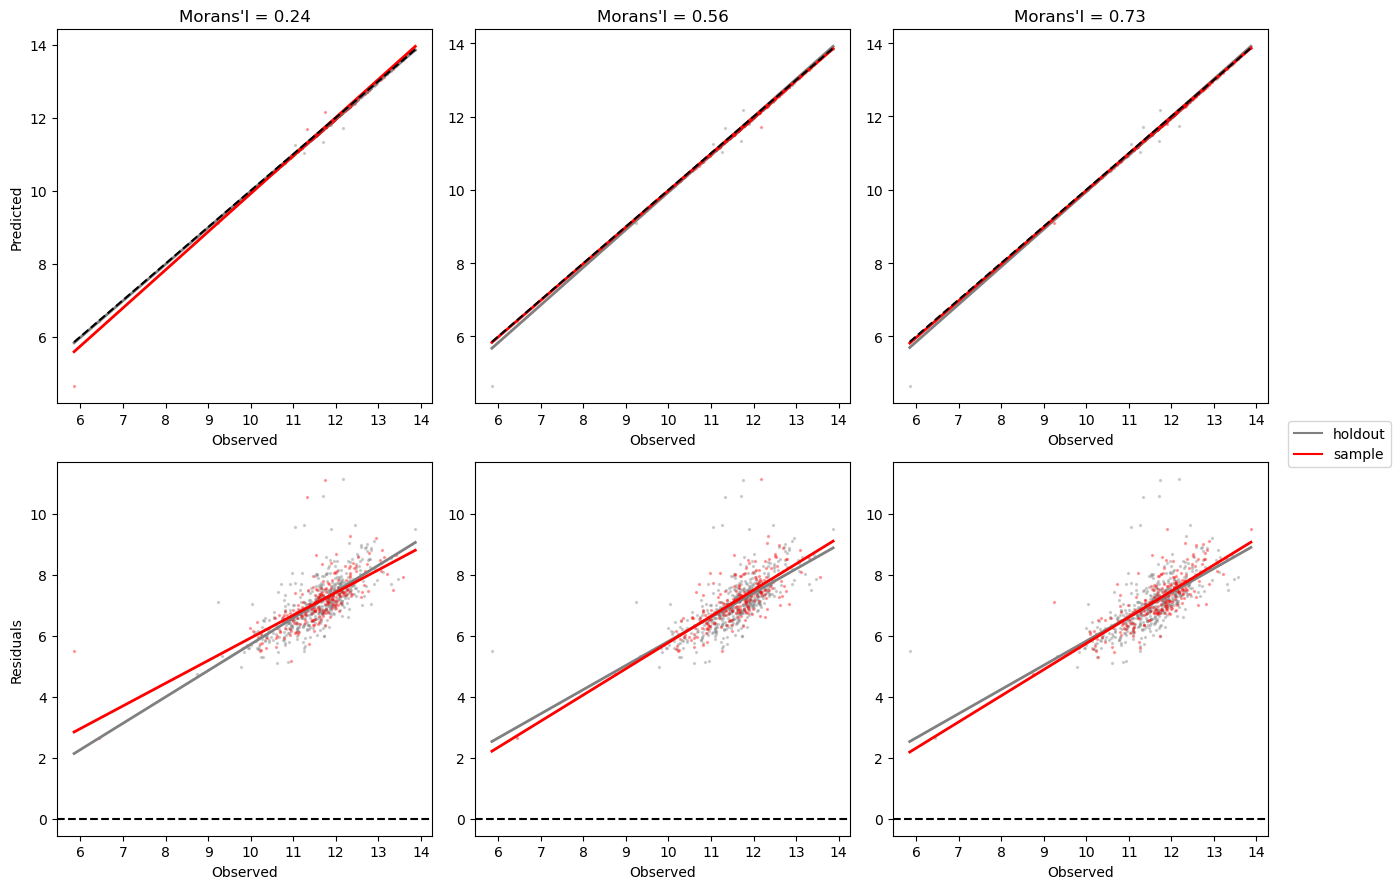

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    "Morans'I = 0.24": r"E:\fake-pomelo\outputs\sample 2\result.csv",
    "Morans'I = 0.56": r"E:\fake-pomelo\outputs\sample 10\result.csv",
    "Morans'I = 0.73": r"E:\fake-pomelo\outputs\sample 16\result.csv"
}

colors = {
    "holdout": "gray",
    "sample": "red"
}

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14,9)
)

for col, (moran, file) in enumerate(files.items()):

    df = pd.read_csv(file)
    # log(x+1)
    df["P_2019"] = np.log1p(df["P_2019"])
    df["predicted"] = np.log1p(df["predicted"])

    # signed log cho residual nếu muốn
    df["residual"] = np.log1p(df["residual"])

    df["Type"] = df["is_train"].map({
        1: "sample",
        0: "holdout"
    })

    ########################
    # TOP: Predicted
    ########################

    ax = axes[0, col]

    xmin = df["P_2019"].min()
    xmax = df["P_2019"].max()

    for t in ["holdout","sample"]:

        tmp = df[df["Type"] == t]

        ax.scatter(
            tmp["P_2019"],
            tmp["predicted"],
            s=2,
            alpha=0.3,
            c=colors[t],
            label=t
        )

        coef = np.polyfit(
            tmp["P_2019"],
            tmp["predicted"],
            1
        )

        x = np.linspace(xmin, xmax, 100)
        y = coef[0]*x + coef[1]

        ax.plot(
            x,y,
            color=colors[t],
            linewidth=2
        )

    # perfect prediction
    ax.plot(
        [xmin,xmax],
        [xmin,xmax],
        'k--'
    )

    ax.set_title(f"{moran}")

    if col == 0:
        ax.set_ylabel("Predicted")

    ax.set_xlabel("Observed")


    ########################
    # BOTTOM: Residual
    ########################

    ax = axes[1,col]

    for t in ["holdout","sample"]:

        tmp = df[df["Type"]==t]

        ax.scatter(
            tmp["P_2019"],
            tmp["residual"],
            s=2,
            alpha=0.3,
            c=colors[t]
        )

        coef = np.polyfit(
            tmp["P_2019"],
            tmp["residual"],
            1
        )

        x=np.linspace(xmin,xmax,100)
        y=coef[0]*x+coef[1]

        ax.plot(
            x,
            y,
            color=colors[t],
            linewidth=2
        )

    ax.axhline(
        0,
        color='black',
        linestyle='--'
    )

    if col==0:
        ax.set_ylabel("Residuals")

    ax.set_xlabel("Observed")

# legend
handles = [
    plt.Line2D([0],[0], color='gray', label='holdout'),
    plt.Line2D([0],[0], color='red', label='sample')
]

fig.legend(
    handles=handles,
    loc='center right'
)

plt.tight_layout(rect=[0,0,0.92,1])
plt.savefig(r"E:\fake-pomelo\moransI\moran_comparison.png",)
plt.show()